In [77]:
# # Description
# 
# Prove that the Noise Reduction model works on a 2D polinomial.

# Add libs folder path to system variables to make the importation of local libraries easier.
# __________________________________________________________________________________________________
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import Dataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [78]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

In [100]:
X_train = np.linspace(-5, 5, 512)
y_train = polinomial_function(X_train)

data_df = pd.DataFrame({'x': X_train, 'y': y_train})

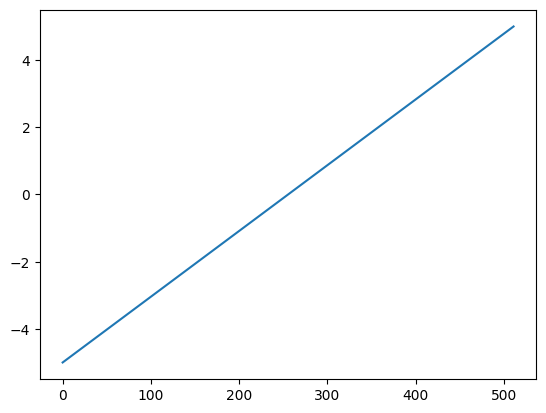

In [101]:
plt.plot(range(len(data_df)), data_df['x'])

In [102]:
data_df

,x,y
0,-5.000000,356.000000
1,-4.980431,348.325431
2,-4.960861,340.760980
3,-4.941292,333.305707
4,-4.921722,325.958677
...,...,...
507,4.921722,-109.351388
508,4.941292,-105.642690
509,4.960861,-101.848457
510,4.980431,-97.967843


In [103]:
scaler = MinMaxScaler()
data_df = pd.DataFrame(scaler.fit_transform(data_df), columns=['x', 'y'])

In [104]:
data_original = data_df.copy()
for sigma in np.arange(0.01, 0.012, 0.01):
        print(1)
        df_noisy = add_gaussian_noise(
                df=data_original.copy(),
                columns=['x'],
                mean=0.0,
                std=sigma
        )
        data_df = pd.concat([data_df, df_noisy])

1


In [105]:
data_df = df_noisy

In [106]:
data_df

,x,y
0,0.017856,1.000000
1,-0.005464,0.986326
2,0.007175,0.972847
3,0.019345,0.959564
4,0.012289,0.946473
...,...,...
507,1.002864,0.170846
508,0.993858,0.177454
509,1.011109,0.184214
510,0.982883,0.191129


In [107]:
batch_size = 128

In [108]:
# limit = int(len(data_df)%batch_size)
# data_df = data_df.iloc[:-limit]

In [109]:
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset2(Dataset):
    def __init__(self, data, window_size):
        """
        Dataset para crear ventanas deslizantes.
        Args:
            data (list or ndarray): Datos originales.
            window_size (int): Tamaño de cada ventana.
        """
        self.data = data.copy()
        self.window_size = window_size

    def __len__(self):
        # Número de ventanas que se pueden generar
        return len(self.data) - self.window_size + 1

    def __getitem__(self, idx):
        # Ventanas deslizantes para X y el valor correspondiente de Y
        X_window = self.data.iloc[idx : idx + self.window_size, 0].values  # Columna X
        Y_value = self.data.iloc[idx : idx + self.window_size, 1].values    # Último valor de la columna Y
        return torch.tensor(X_window, dtype=torch.float32), torch.tensor(Y_value, dtype=torch.float32)


In [110]:
# Create Datasets for DataLoaders
noisy_dataset = SlidingWindowDataset2(
    data=data_df,
    window_size=128
)

# Create the dataloaders
train_dataloader = DataLoader(noisy_dataset, batch_size=32, shuffle=False, num_workers=0)

KeyboardInterrupt: 

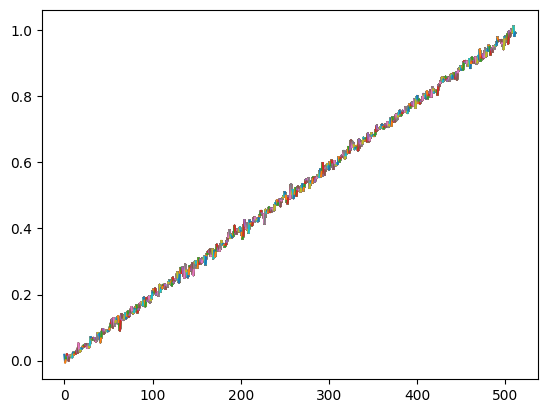

In [116]:
for i, x in enumerate(noisy_dataset):
    plt.plot(range(i, i+len(x[0])), x[0].detach().numpy())

In [91]:
denoiser = DenoisingAutoencoder(
    input_dim=batch_size,
    latent_dim=128,
).to(device)

In [92]:
# Set model parameters and create the model Trainer object
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(denoiser.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=denoiser,
    train_generator=train_dataloader,
    val_generator=train_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(
        CHECKPOINT_PATH, 'denoising_autoencoder'
    ),
)

In [93]:
# denoiser = torch.load(os.path.join(CHECKPOINT_PATH, 'denoising_autoencoder.pth'))

In [94]:
# Train the model
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)


Training is started!


Epochs loop:  70%|██████▉   | 349/500 [00:04<00:01, 79.60epoch/s, Train loss: 6.563345964874273e-16 - Val loss: 5.227795235620528e-16]  

Training stopped as validation loss did not improve for 15 epochs.


In [95]:
def reconstruct_tensor(y_pred, tensor_size, window_size):
    tensor_reconstructed = torch.zeros((tensor_size)).to(device)
    for i in range(len(y_pred)):
        tensor_reconstructed[i:i+window_size] += y_pred[i][0]
    for i in range(1, len(y_pred)):
        tensor_reconstructed[i] /= np.min([i+1, window_size, tensor_size-i])

    return tensor_reconstructed

In [96]:
y_pred_noisy = trainer_basic.eval_dataloader(train_dataloader)

In [97]:
flattened_tensor = reconstruct_tensor(y_pred_noisy, len(data_df), 128)

In [98]:
flattened_tensor

tensor([ 1.0000e+00,  9.4616e-01,  8.9542e-01,  8.4767e-01,  8.0280e-01,
         7.6071e-01,  7.2129e-01,  6.8445e-01,  6.5009e-01,  6.1811e-01,
         5.8841e-01,  5.6090e-01,  5.3549e-01,  5.1208e-01,  4.9060e-01,
         4.7094e-01,  4.5303e-01,  4.3678e-01,  4.2211e-01,  4.0893e-01,
         3.9718e-01,  3.8676e-01,  3.7761e-01,  3.6965e-01,  3.6281e-01,
         3.5701e-01,  3.5219e-01,  3.4828e-01,  3.4522e-01,  3.4293e-01,
         3.4136e-01,  3.4045e-01,  3.4013e-01,  3.4035e-01,  3.4105e-01,
         3.4218e-01,  3.4369e-01,  3.4552e-01,  3.4762e-01,  3.4995e-01,
         3.5245e-01,  3.5509e-01,  3.5783e-01,  3.6061e-01,  3.6341e-01,
         3.6617e-01,  3.6888e-01,  3.7148e-01,  3.7395e-01,  3.7626e-01,
         3.7838e-01,  3.8027e-01,  3.8192e-01,  3.8329e-01,  3.8437e-01,
         3.8513e-01,  3.8555e-01,  3.8562e-01,  3.8531e-01,  3.8461e-01,
         3.8351e-01,  3.8200e-01,  3.8007e-01,  3.7770e-01,  3.7489e-01,
         3.7164e-01,  3.6794e-01,  3.6380e-01,  3.5

In [99]:
# Show the metrics
gt_values = data_df['y'].values
predicted_values = flattened_tensor.cpu().detach().numpy()

mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
# mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
nn_benchmark = {
    'nn': {
        "MSE: ": mse,
        "RMSE: ": rmse,
        "MAE: ": mae,
        # "MAPE: ": mape,
        "R2: ": r_squared
    }
}
nn_benchmark

{'nn': {'MSE: ': 4.086657977207631e-16,
  'RMSE: ': 2.0215484107999075e-08,
  'MAE: ': 1.4677209971263733e-08,
  'R2: ': 0.9999999999999905}}